In [10]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import lgamma
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import connected_components
PHOTON_COL = "photon_id"
N_true = 100

In [11]:
df = pd.read_pickle("../data/raw/data.pkl")

In [12]:
def build_dt_dr_gate(dfw, DT_MAX_NS=50.0, DR_MAX_CM=15.0, eps=1e-12):
    """Compute dt, dr and a hard gate matrix; return dt_pos/dr_pos with inf outside gate."""
    t = dfw["time_meas_ns"].to_numpy()
    x = dfw["x_meas_cm"].to_numpy()
    y = dfw["y_meas_cm"].to_numpy()
    z = dfw["z_meas_cm"].to_numpy()
    N = len(dfw)

    dt = np.abs(t[:, None] - t[None, :])
    dr = np.sqrt((x[:, None]-x[None, :])**2 + (y[:, None]-y[None, :])**2 + (z[:, None]-z[None, :])**2)

    gate = (dt <= DT_MAX_NS) & (dr <= DR_MAX_CM)
    np.fill_diagonal(gate, False)

    dt_pos = np.where(dt <= 0, eps, dt)
    dr_pos = np.where(dr <= 0, eps, dr)

    dt_pos[~gate] = np.inf
    dr_pos[~gate] = np.inf
    np.fill_diagonal(dt_pos, np.inf)
    np.fill_diagonal(dr_pos, np.inf)

    neighbors = [np.where(gate[i])[0] for i in range(N)]
    return t, N, dt_pos, dr_pos, gate, neighbors


In [13]:
def log_gamma_pdf(d, alpha, sigma):
    # Gamma(shape=alpha, scale=sigma) logpdf for d>0
    return (alpha - 1.0) * np.log(d) - (d / sigma) - alpha * np.log(sigma) - lgamma(alpha)

def sample_inv_gamma(rng, a, b):
    # sigma ~ InvGamma(a,b)  <=>  1/sigma ~ Gamma(a, rate=b)
    y = rng.gamma(shape=a, scale=1.0/b)
    return 1.0 / y

def gibbs_bdc_coassign(
    dt_pos, dr_pos, gate, neighbors,
    alpha_shape=2.0,
    a_sig=2.0, b_t=15.0, b_r=5.0,
    alpha_crp=0.05,
    n_iters=1000, burnin=400, thin=5,
    KMAX=None, seed=0, verbose_every=100
):
    """
    Bayesian distance clustering (simplified):
      - within-cluster dt ~ Gamma(alpha_shape, sigma_t[h])
      - within-cluster dr ~ Gamma(alpha_shape, sigma_r[h])
      - sigma_t, sigma_r ~ InvGamma(a_sig, b_t/b_r)
      - z ~ CRP(alpha_crp)
      - hard gate: pairs outside gate cannot be in same cluster
    Returns: coassign (NxN), trace dict, final z
    """
    rng = np.random.default_rng(seed)
    N = dt_pos.shape[0]
    if KMAX is None:
        KMAX = min(N, 500)

    # init labels
    z = rng.integers(0, KMAX, size=N)
    members = [set() for _ in range(KMAX)]
    for i, h in enumerate(z):
        members[h].add(i)

    # init sigmas
    sigma_t = np.array([sample_inv_gamma(rng, a_sig, b_t) for _ in range(KMAX)], float)
    sigma_r = np.array([sample_inv_gamma(rng, a_sig, b_r) for _ in range(KMAX)], float)

    def pick_empty_label():
        for h in range(KMAX):
            if len(members[h]) == 0:
                return h
        return None

    def cluster_valid_with(i, h):
        for j in members[h]:
            if not gate[i, j]:
                return False
        return True

    def log_like_add_norm(i, h):
        m = len(members[h])
        if m == 0:
            return 0.0
        st, sr = sigma_t[h], sigma_r[h]
        ll = 0.0
        for j in members[h]:
            ll += log_gamma_pdf(dt_pos[i, j], alpha_shape, st)
            ll += log_gamma_pdf(dr_pos[i, j], alpha_shape, sr)
        return ll / m  # normalize by cluster size, see Dunson et al.

    def update_sigmas(h):
        idx = list(members[h])
        m = len(idx)
        if m < 2:
            return (sample_inv_gamma(rng, a_sig, b_t),
                    sample_inv_gamma(rng, a_sig, b_r))

        sum_t = 0.0
        sum_r = 0.0
        pair_count = 0
        for a in range(m):
            ia = idx[a]
            for b in range(a + 1, m):
                ib = idx[b]
                if not np.isfinite(dt_pos[ia, ib]):
                    continue
                sum_t += dt_pos[ia, ib]
                sum_r += dr_pos[ia, ib]
                pair_count += 1

        st = sample_inv_gamma(rng, a_sig + alpha_shape * pair_count, b_t + sum_t)
        sr = sample_inv_gamma(rng, a_sig + alpha_shape * pair_count, b_r + sum_r)
        return st, sr

    coassign = np.zeros((N, N), float)
    kept = 0
    trace_nonempty = []
    trace_mean_size = []

    for it in range(n_iters):
        # update sigmas
        for h in range(KMAX):
            sigma_t[h], sigma_r[h] = update_sigmas(h)

        # update assignments
        for i in range(N):
            h_old = z[i]
            members[h_old].remove(i)

            # candidate clusters: those containing any gated neighbor
            cand_set = set(z[j] for j in neighbors[i])
            cand = [h for h in cand_set if len(members[h]) > 0]

            new_label = pick_empty_label()
            if new_label is not None:
                cand.append("NEW")

            logp = np.full(len(cand), -np.inf, float)
            for k, h in enumerate(cand):
                if h == "NEW":
                    logp[k] = np.log(alpha_crp)
                else:
                    if not cluster_valid_with(i, h):
                        continue
                    log_prior = np.log(len(members[h]))  # CRP
                    log_like = log_like_add_norm(i, h)
                    logp[k] = log_prior + log_like

            mmax = np.max(logp)
            if not np.isfinite(mmax):
                h_new = new_label if new_label is not None else h_old
            else:
                p = np.exp(logp - mmax)
                p /= p.sum()
                choice = rng.choice(len(cand), p=p)
                h_chosen = cand[choice]
                h_new = new_label if h_chosen == "NEW" else h_chosen

            z[i] = h_new
            members[h_new].add(i)

        # trace
        sizes = np.array([len(m) for m in members], int)
        nonempty = int((sizes > 0).sum())
        mean_size = float(sizes[sizes > 0].mean()) if nonempty else 0.0
        trace_nonempty.append(nonempty)
        trace_mean_size.append(mean_size)

        # collect coassign
        if it >= burnin and ((it - burnin) % thin == 0):
            kept += 1
            for h in range(KMAX):
                idx = np.fromiter(members[h], dtype=int, count=len(members[h]))
                if idx.size:
                    coassign[np.ix_(idx, idx)] += 1.0

        if verbose_every and (it % verbose_every == 0):
            print(f"iter {it:4d} | nonempty: {nonempty:4d} | mean size: {mean_size:.2f} | kept: {kept}")

    coassign /= max(1, kept)
    trace = {
        "nonempty": np.array(trace_nonempty),
        "mean_size": np.array(trace_mean_size),
        "kept": kept,
        "burnin": burnin,
        "thin": thin
    }
    return coassign, trace, z


In [14]:
def z_from_coassign_threshold(coassign, gate=None, P_thresh=0.3):
    """
    Turn posterior coassign into a hard clustering by thresholding edges and
    taking connected components. Optionally require gate as well.
    """
    A = (coassign >= P_thresh)
    if gate is not None:
        A = A & gate
    np.fill_diagonal(A, True)

    n_comp, labels = connected_components(A.astype(int), directed=False)
    return labels, n_comp

def variation_of_information(z_true, z_hat):
    """
    VI(z_true, z_hat) = H(z_true) + H(z_hat) - 2 I(z_true, z_hat)
    computed from counts; uses natural log (units: nats). Always >= 0.
    """
    z_true = np.asarray(z_true)
    z_hat = np.asarray(z_hat)
    N = len(z_true)

    # relabel to contiguous 0..K-1
    _, zt = np.unique(z_true, return_inverse=True)
    _, zh = np.unique(z_hat, return_inverse=True)

    Kt = zt.max() + 1
    Kh = zh.max() + 1

    # contingency table
    cont = np.zeros((Kt, Kh), dtype=np.int64)
    np.add.at(cont, (zt, zh), 1)

    p_ij = cont / N
    p_i = p_ij.sum(axis=1, keepdims=True)
    p_j = p_ij.sum(axis=0, keepdims=True)

    # Entropies
    def H(p):
        p = p[p > 0]
        return -np.sum(p * np.log(p))

    Ht = H(p_i.ravel())
    Hh = H(p_j.ravel())

    # mutual information
    nz = p_ij > 0
    I = np.sum(p_ij[nz] * np.log(p_ij[nz] / (p_i @ p_j)[nz]))

    return (Ht + Hh - 2*I)

def evaluate_partition(dfw, z_hat, photon_col=PHOTON_COL):
    z_true = dfw[photon_col].astype("category").cat.codes.to_numpy()
    ari = adjusted_rand_score(z_true, z_hat)
    vi = variation_of_information(z_true, z_hat)
    return ari, vi


In [15]:
t, N, dt_pos, dr_pos, gate, neighbors = build_dt_dr_gate(df, DT_MAX_NS=5000.0, DR_MAX_CM=15.0)
print(N, "interactions in window")
# run Bayesian Gibbs (coassign posterior)
coassign, trace, z_last = gibbs_bdc_coassign(
    dt_pos, dr_pos, gate, neighbors,
    alpha_shape=2.0,
    a_sig=2.0, b_t=15.0, b_r=5.0,
    alpha_crp=0.005,
    n_iters=1000, burnin=200, thin=5,
    KMAX=min(N, 500),
    seed=0,
    verbose_every=10
)

print("kept samples:", trace["kept"])


244 interactions in window
iter    0 | nonempty:  138 | mean size: 1.77 | kept: 0
iter   10 | nonempty:  135 | mean size: 1.81 | kept: 0
iter   20 | nonempty:  115 | mean size: 2.12 | kept: 0
iter   30 | nonempty:  124 | mean size: 1.97 | kept: 0
iter   40 | nonempty:  129 | mean size: 1.89 | kept: 0
iter   50 | nonempty:  124 | mean size: 1.97 | kept: 0
iter   60 | nonempty:  119 | mean size: 2.05 | kept: 0
iter   70 | nonempty:  134 | mean size: 1.82 | kept: 0
iter   80 | nonempty:  125 | mean size: 1.95 | kept: 0
iter   90 | nonempty:  136 | mean size: 1.79 | kept: 0
iter  100 | nonempty:  128 | mean size: 1.91 | kept: 0
iter  110 | nonempty:  128 | mean size: 1.91 | kept: 0
iter  120 | nonempty:  133 | mean size: 1.83 | kept: 0
iter  130 | nonempty:  127 | mean size: 1.92 | kept: 0
iter  140 | nonempty:  125 | mean size: 1.95 | kept: 0
iter  150 | nonempty:  129 | mean size: 1.89 | kept: 0
iter  160 | nonempty:  127 | mean size: 1.92 | kept: 0
iter  170 | nonempty:  130 | mean size

In [20]:
print(np.log(N_true), "log true photons")
print(f"Good VI: {np.log(N_true) * 0.5:.3f} or lower")


4.605170185988092 log true photons
Good VI: 2.303 or lower


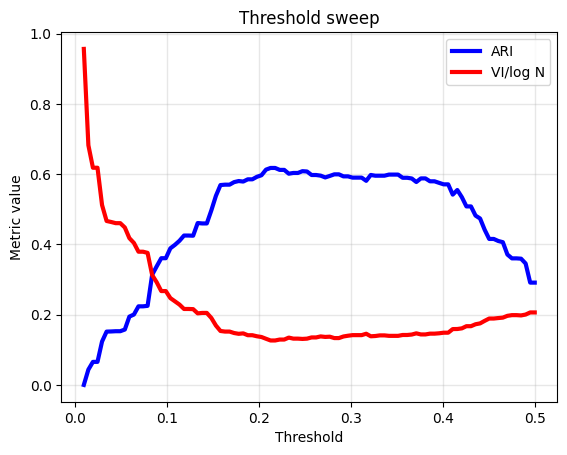

In [22]:
thres = np.linspace(0.01,0.5,100)
zs = []
aris = []
vis = []
for th in thres:
    z_tmp, K_tmp = z_from_coassign_threshold(coassign, gate=gate, P_thresh=th)
    zs.append(z_tmp)
    ari_tmp, vi_tmp = evaluate_partition(df, z_tmp)
    aris.append(ari_tmp)
    vis.append(vi_tmp)
plt.plot(thres, aris, label="ARI", color='blue',linewidth=3)
plt.plot(thres, vis/np.log(N_true), label="VI/log N",color='red',linewidth=3)
plt.grid(alpha=0.3,linewidth=1.0)
plt.title('Threshold sweep')
plt.xlabel(r"Threshold")
plt.legend()
plt.ylabel('Metric value')
plt.show()

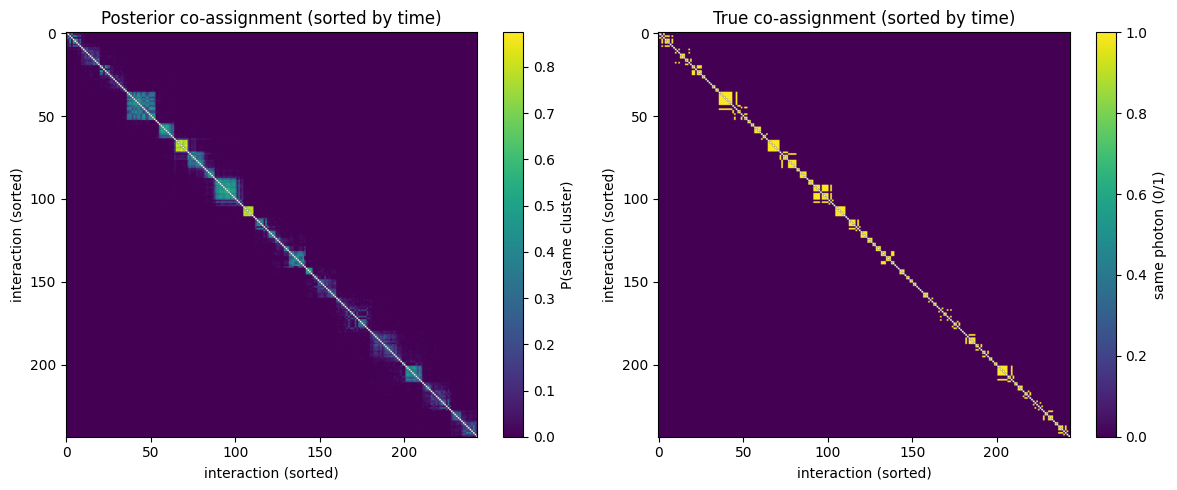

In [23]:
import matplotlib.pyplot as plt
import numpy as np

order = np.argsort(t)

# posterior
P_post = coassign[order][:, order]
Pp_post = P_post.copy()
np.fill_diagonal(Pp_post, np.nan)

# truth
z_true = df[PHOTON_COL].astype("category").cat.codes.to_numpy()
z_true_s = z_true[order]
P_true = (z_true_s[:, None] == z_true_s[None, :]).astype(float)
Pp_true = P_true.copy()
np.fill_diagonal(Pp_true, np.nan)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Pp_post, vmin=0, vmax=np.nanmax(Pp_post), aspect="auto")
plt.title("Posterior co-assignment (sorted by time)")
plt.xlabel("interaction (sorted)")
plt.ylabel("interaction (sorted)")
plt.colorbar(label="P(same cluster)")

plt.subplot(1, 2, 2)
plt.imshow(Pp_true, vmin=0, vmax=1, aspect="auto")
plt.title("True co-assignment (sorted by time)")
plt.xlabel("interaction (sorted)")
plt.ylabel("interaction (sorted)")
plt.colorbar(label="same photon (0/1)")

plt.tight_layout()
plt.show()
